# Práctica 2.3. Implementación RNN y LSTM Keras

Objetivo: Implementar RNNs y LSTMs para una tarea de clasificación  

Anteriormente se realizó la implementación de una red neuronal recurrente desde cero con un conjunto de análisis de sentimientos [Implementación de RNN](https://github.com/BogdanRivera/ai-repository/blob/main/NLP/Procesamiento_de_lenguaje_natural/rnn_from_scratch/2_rnn_implementation.ipynb). La práctica se divide en dos partes. En la primera se realizará el entrenamiento de una RNN simple y LSTM sobre el conjunto IMBD con la librería de Keras, seguido de la implementación de una red más compleja y finalmente la realización de una tercera red usadas en la literatura. En la segunda parte, se realiza el mismo enfoque sobre otro conjunto de datos de análisis de sentimientos con el fin de realizar la comparación de los modelos de redes.

## Parte 1. Base de datos IMDB de la librería tensorflow.keras.datasets

Inicialmente se tiene que cargar el conjunto de datos a partir de la librería de Keras.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

data = keras.datasets.imdb

(x_train, y_train), (x_test, y_test) = data.load_data(num_words=10000)
print(f"Tamaño de x_train: {x_train.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de x_test: {x_test.shape}")
print(f"Tamaño de y_test: {y_test.shape}")

Tamaño de x_train: (25000,)
Tamaño de y_train: (25000,)
Tamaño de x_test: (25000,)
Tamaño de y_test: (25000,)


Para evitar variaciones en las entradas, se puede realizar el padding para fijar las entradas y rellenar con ceros los espacios faltantes.

In [ ]:
longitud_maxima = 500
x_train = pad_sequences(x_train, maxlen=longitud_maxima, padding='post')
x_test = pad_sequences(x_train, maxlen=longitud_maxima, padding='post')

In [ ]:
print(f"Forma de x_train después del padding: {x_train.shape}")
print("Ejemplo: ",x_train[0])

Forma de x_train después del padding: (25000, 500)
Ejemplo:  [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22   21  134  476
   26  480    5 

Con esto, las entradas ya quedan en un tamaño fijo (llamado padding).

De igual manera para graficar las pérdidas y la precisión, es necesario crear una función.


In [ ]:
import matplotlib.pyplot as plt

def graficos(history, title):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Precisión (Entrenamiento)')
    plt.plot(epochs, val_acc, 'ro-', label='Precisión (Validación)')
    plt.title('Precisión de Entrenamiento y Validación - ' + title)
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Pérdida (Entrenamiento)')
    plt.plot(epochs, val_loss, 'ro-', label='Pérdida (Validación)')
    plt.title('Pérdida de Entrenamiento y Validación - ' + title)
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.tight_layout()
    plt.show()

## 1.1 Construcción y entrenamiento de la red neuronal simple.

Una vez realizado el preprocesamiento, se realiza la clase de la red neuronal simple.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

class SimpleRNNModel(Sequential):
    def __init__(self, vocab_size, embedding_dim, max_length, rnn_units):

        super().__init__()

        self.add(Embedding(input_dim=vocab_size,
                           output_dim=embedding_dim,
                           input_length=max_length))

        self.add(SimpleRNN(units=rnn_units))


        self.add(Dense(units=1, activation='sigmoid'))

Como se vió en el anterior notebook, se hacen uso de los mismos parámetros.

In [ ]:
t_vocabulario = 10000
embedding_dim = 32
rnn_units = 64

Entre los hiperparámetros se hace uso del tamaño del vocabulario para la entrada de la capa de embedding, en el caso de la salida de dicha capa se hace uso de un número potencia de 2 (32 para este caso) mientras que la longitud de la entrada se ajustó a 500 (como los paddings). En la capa oculta se hace uso del mismo número de neuronas que los embeddings. Finalmente la salida consta únicamente de una sola neurona con la salida sigmoide. Esto con la finalidad de realizar únicamente clasificación binaria.


Inicialmente se realizaron pruebas y se eligieron 15 épocas de entrenamiento, así como un 80% de los datos en entrenamiento y 20% de prueba.

In [ ]:
model = SimpleRNNModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    rnn_units=rnn_units
)

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

history = model.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 171ms/step - accuracy: 0.4986 - loss: 0.6963 - val_accuracy: 0.5058 - val_loss: 0.6928
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.5286 - loss: 0.6910 - val_accuracy: 0.5050 - val_loss: 0.6972
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.5190 - loss: 0.6904 - val_accuracy: 0.5072 - val_loss: 0.6938
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.5214 - loss: 0.6883 - val_accuracy: 0.5096 - val_loss: 0.6928
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.5140 - loss: 0.6824 - val_accuracy: 0.5066 - val_loss: 0.7139
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.5210 - loss: 0.6911 - val_accuracy: 0.5090 - val_loss: 0.6924
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.5286 - loss: 0.6854 - val_accuracy: 0.4972 - val_loss: 0.6971
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 145ms/step - accuracy: 0.5221 - loss: 0

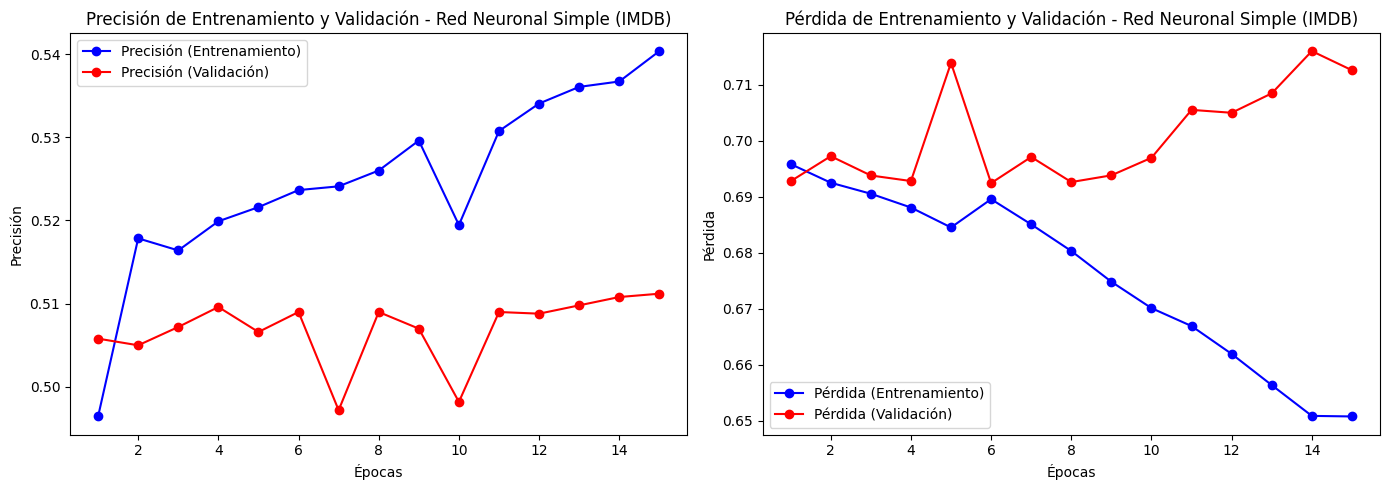

In [ ]:
graficos(history,"Red Neuronal Simple (IMDB)")

Como se puede observar en la gráfica de la izquierda, la línea de precisión en entrenamiento sube de manera constante. Esto quiere decir que el modelo es muy bueno para "memorizar" las respuestas correctas con las que se ha entrenado pero en la gráfica de validación no ocurre lo mismo, el cual se mantienen entre 45 y 51% en promedio, por lo que no puede generalizar los datos, solo los está aprendiendo.

De igual manera, en la gráfica de la derecha, la gráfica de perdida baja de manera consistente el cual significa que el modelo está minimizando el error de los datos de entrenamiento. Sin embargo, la línea de validación muestra que aumenta y se mantiene alta lo cual no disminuye, lo que indica de manera general que el modelo no está aprendiendo a generalizar.

Evaluación de los datos de prueba.

In [ ]:
resultados_simplernn = model.evaluate(x_test, y_test, verbose=2)
print(f"Pérdida: {resultados_simplernn[0]:.4f}")
print(f"Precisión: {resultados_simplernn[1]*100:.2f}%")

782/782 - 19s - 24ms/step - accuracy: 0.5000 - loss: 0.7655
Pérdida: 0.7655
Precisión: 50.00%


Como se puede observar, una red simple no es suficiente para que se generalice correctamente los datos, tanto en entrenamiento y prueba, además de tener una pérdida muy arriba del promedio.

### 1.2. Construcción y entrenamiento de la red LSTM.

Una vez implementado el modelo simple de una red neuronal recurrente simple, el siguiente paso es realizar lo mismo pero con una red LSTM.

Creación de la clase.

Para la creación de la red lstm únicamente se realiza el cambio de la capa oculta por el módulo lstm directamente de Keras.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

class LSTMModel(Sequential):

    def __init__(self, vocab_size, embedding_dim, max_length, rnn_units):

        super().__init__()

        self.add(Embedding(input_dim=vocab_size,
                           output_dim=embedding_dim,
                           input_length=max_length))
        self.add(LSTM(units=rnn_units))

        self.add(Dense(units=1, activation='sigmoid'))

Para el entrenamiento de la red se usan exactamente los mismos parámetros.

In [ ]:
model_lstm = LSTMModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    rnn_units=rnn_units
)


In [ ]:
model_lstm.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model_lstm.summary()

history_lstm = model_lstm.fit(x_train, y_train,
                    epochs=15,
                    batch_size=64,
                    validation_split=0.2)

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 100s 312ms/step - accuracy: 0.5031 - loss: 0.6932 - val_accuracy: 0.5100 - val_loss: 0.6926
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 312ms/step - accuracy: 0.5219 - loss: 0.6900 - val_accuracy: 0.5172 - val_loss: 0.6874
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 138s 299ms/step - accuracy: 0.5282 - loss: 0.7072 - val_accuracy: 0.5142 - val_loss: 0.6887
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 300ms/step - accuracy: 0.5395 - loss: 0.6738 - val_accuracy: 0.5184 - val_loss: 0.6869
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 299ms/step - accuracy: 0.5367 - loss: 0.6638 - val_accuracy: 0.5284 - val_loss: 0.6836
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 302ms/step - accuracy: 0.5441 - loss: 0.6412 - val_accuracy: 0.5158 - val_loss: 0.7008
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 97s 308ms/step - accuracy: 0.5625 - loss: 0.6362 - val_accuracy: 0.5144 - val_loss: 0.6858
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 312ms/step - accuracy: 0.5279 - los

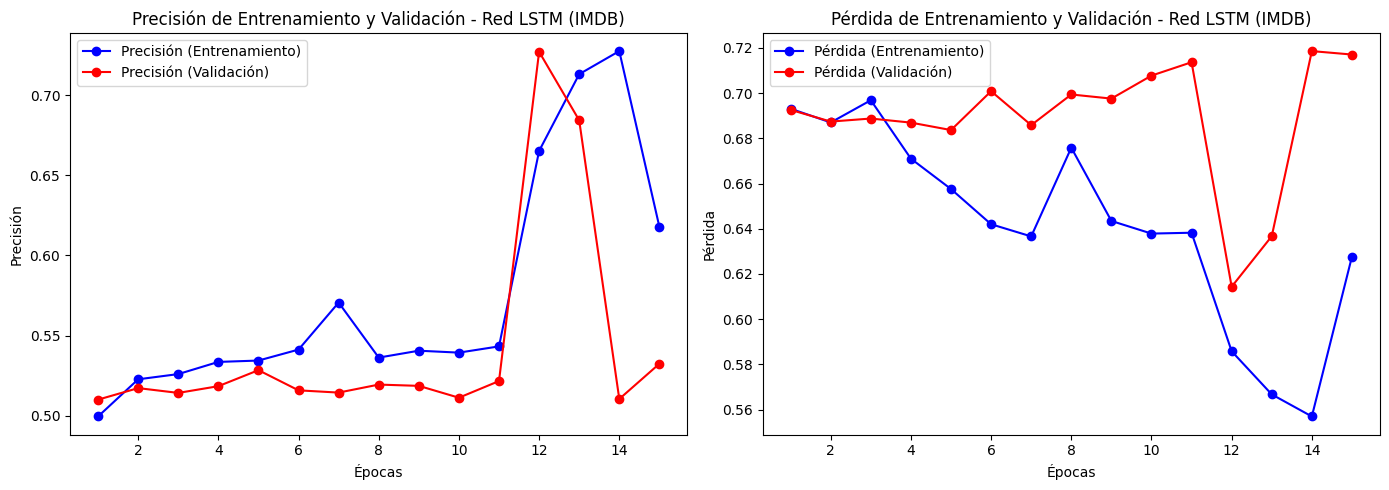

In [ ]:
graficos(history_lstm,"Red LSTM (IMDB)")

Al igual que la red neuronal simple, esta red también se mantiene estancada en una precisión entre 50 y poco más de 55% tanto en entrenamiento como en prueba. Aquí se puede observar que el modelo de alguna manera sube su precisión después de la época 11. Esto quiere decir que su entrenamiento es muy impreciso ya que la precisión sube a aproximadamente 74% y posteriormente se desploma a los mismos valores que se tenian anteriormente.

En cuanto a la gráfica de la derecha ocurre lo mismo que con la red simple el cual indica que no hay una conclusión estable con respecto al aprendizaje, por lo que se podría pensar nuevamente que es un caso de sobreajuste de los datos.

In [ ]:
resultados_lstm = model_lstm.evaluate(x_test, y_test, verbose=2)
print(f"Pérdida: {resultados_lstm[0]:.4f}")
print(f"Precisión: {resultados_lstm[1]*100:.2f}%")

782/782 - 44s - 57ms/step - accuracy: 0.5018 - loss: 0.8108
Pérdida: 0.8108
Precisión: 50.18%


Al igual que el modelo anterior, no logra generalizar correctamente los datos.

## 1.3. Exploración de propuestas basadas en redes recurrentes.

De acuerdo a la literatura en general existen diversas redes neuronales recurrentes que pueden ser utilizadas para distintas tareas ( [5 tipos de redes neuronales recurrentes](https://www.analyticsvidhya.com/blog/2021/08/sentiment-analysis-using-bidirectional-stacked-lstm/)), las cuales son lstm bidireccional, Unidad recurrente cerrada (GRU), Convolucional y con mecanismo de atención. Haciendo énfasis específicamente de una red lstm bidireccional, esta funciona a partir del procesamiento de la secuencia en ambas direcciones, es decir procesa la secuencia desde el inicio hasta el final y viceversa. Esto permite capturar el contexto pasado y futuro para cada punto de la secuencia. Por otra parte, una LSTM puede ser apilada, es decir se conectan en cascada donde la salida de una capa LSTM se convierte en una entrada de la siguiente. Esto puede mejorar la capacidad de la red para aprender patrones más complejos. Este enfoque se ha aplicado a diversos trabajos como clasificación de tweets para evitar contenido multimedia falso [Clasificación de tuits deepfake mediante Bi-LSTM apilado e incrustación de palabras](https://pmc.ncbi.nlm.nih.gov/articles/PMC8576542/) o para la clasificación de análisis de sentimientos [Sentiment Analysis Using Bidirectional Stacked LSTM](https://www.analyticsvidhya.com/blog/2021/08/sentiment-analysis-using-bidirectional-stacked-lstm/).

Con respecto a lo anterior, es de interés saber como se aplica. Es por ello que se basa el siguiente trabajo de clasificación de audio para poder implementar la red lstm [Stacked BiDirectional LSTM - Test Acc: 95%
](https://www.kaggle.com/code/mkowoods/stacked-bidirectional-lstm-test-acc-95/input).

Implementando la red lstm bidireccional apilada (Stacked BiDirectional LSTM).

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dropout,
    Dense
)

class LSTMBIStackModel(Sequential):

    def __init__(self, vocab_size, embedding_dim, max_length, lstm_units, dropout_rate):

        super().__init__()

        self.add(Embedding(input_dim=vocab_size,
                           output_dim=embedding_dim,
                           input_length=max_length))

        self.add(Bidirectional(LSTM(
            units=lstm_units,
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate,
            return_sequences=True
        )))

        self.add(Bidirectional(LSTM(
            units=lstm_units,
            dropout=dropout_rate,
            recurrent_dropout=dropout_rate,
            return_sequences=False
        )))

        self.add(Dropout(dropout_rate))

        self.add(Dense(units=64, activation='relu'))

        self.add(Dense(units=1, activation='sigmoid'))

En comparación con los otros modelos, se eligieron otros hiperparámetros, para mostrar si con la nueva red mejoraba o empeoraba.

In [ ]:
embedding_dim = 64
lstm_units = 128
dropout = 0.4
model_bi_lstm = LSTMBIStackModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    lstm_units=lstm_units,
    dropout_rate=dropout
)
model_bi_lstm.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_bi_lstm.summary()

history_bi_lstm = model_bi_lstm.fit(x_train, y_train,
                    epochs=2,
                    batch_size=64,
                    validation_split=0.2)

Model: "lstmbi_stack_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 2248s 7s/step - accuracy: 0.5705 - loss: 0.6602 - val_accuracy: 0.7880 - val_loss: 0.4695
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 2220s 7s/step - accuracy: 0.7922 - loss: 0.4586 - val_accuracy: 0.8316 - val_loss: 0.4093


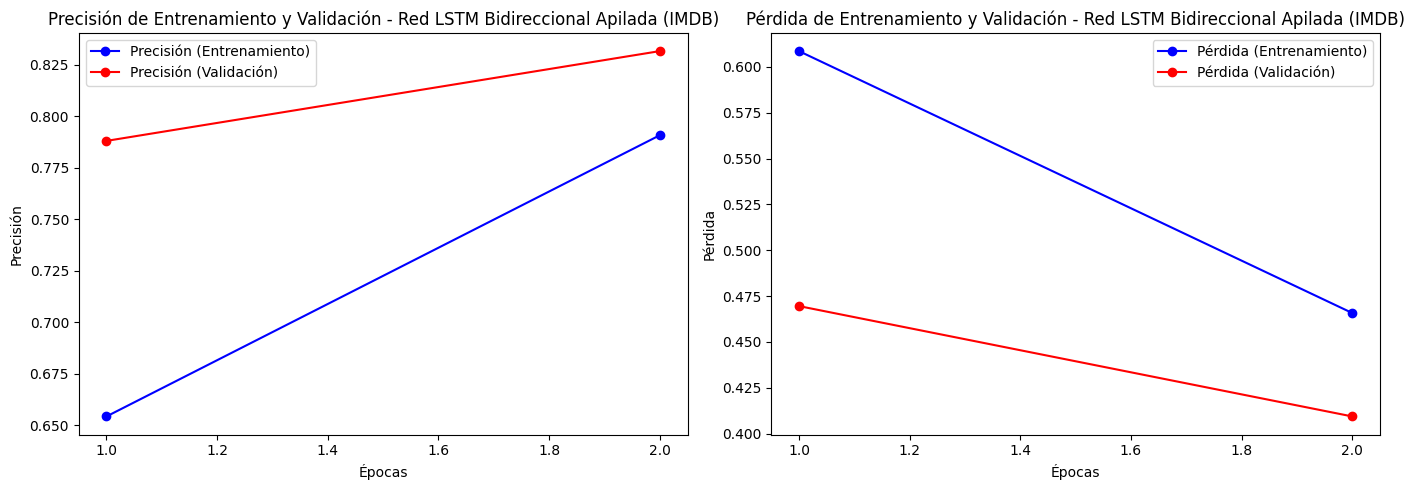

In [ ]:
graficos(history_bi_lstm,"Red LSTM Bidireccional Apilada (IMDB)")

A comparación de las otras 2 redes, esta red si tiende a generalizar los datos. En cuanto a la gráfica de la izquierda, esta indica que las precisiones están mejorando lo que muestra un buen aprendizaje. De igual manera, en la gráfica de la derecha, esta muestra que ambas pérdidas están bajando, lo que confirma que el modelo está generalizando de mejor manera.

Para este caso, se eligieron únicamente 2 épocas debido a que la red estaba tardando mucho tiempo en entrenarse (aproximadamente 1:30 horas para estas dos épocas únicamente).

In [ ]:
resultados_lstm_bi = model_bi_lstm.evaluate(x_test, y_test, verbose=2)
print(f"Pérdida: {resultados_lstm_bi[0]:.4f}")
print(f"Precisión: {resultados_lstm_bi[1]*100:.2f}%")

782/782 - 568s - 727ms/step - accuracy: 0.4978 - loss: 1.0667
Pérdida: 1.0667
Precisión: 49.78%


Con respecto a la precisión promedio, al ser 2 épocas este resultado es "poco viable" ya que son pocas épocas para predecir un promedio general aceptable. En las gráficas se muestra que la precisión es aproximadamente 80%.

## Parte 2. Base de datos Sentiment and Emotion Analysis Dataset

Para la parte 2, se hará uso del siguiente dataset: [Sentiment and Emotion Analysis Dataset](https://www.kaggle.com/datasets/kushagra3204/sentiment-and-emotion-analysis-dataset).

A diferencia de la anterior base de datos, esta tiene que ser preprocesada para adaptarse a las redes.


Carga de los datos.

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = kagglehub.dataset_download("kushagra3204/sentiment-and-emotion-analysis-dataset")

print("Path to dataset files:", path)

df = pd.read_csv('/kaggle/input/sentiment-and-emotion-analysis-dataset/archive/combined_sentiment_data.csv')
print("Primeras 5 filas del dataset: \n",df.head())

Using Colab cache for faster access to the 'sentiment-and-emotion-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-and-emotion-analysis-dataset
Primeras 5 filas del dataset: 
                                             sentence sentiment
0  So there is no way for me to plug it in here i...  negative
1                        Good case, Excellent value.  positive
2                             Great for the jawbone.  positive
3  Tied to charger for conversations lasting more...  negative
4                                  The mic is great.  positive


Separación de los datos en train/test.

In [ ]:
from sklearn.model_selection import train_test_split

df['sentiment_labels'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X_train, X_test, y_train, y_test = train_test_split(df['sentence'],
                  df['sentiment_labels'], test_size = 0.2, random_state=42)

print("Longitud de X_train: ", X_train.shape)
print("Longitud de X_test:  ", X_test.shape)
print("Longitud de y_train: ", y_train.shape)
print("Longitud de y_test:  ", y_test.shape)

Longitud de X_train:  (2647,)
Longitud de X_test:   (662,)
Longitud de y_train:  (2647,)
Longitud de y_test:   (662,)


Preprocesamiento y embeddings.

En este apartado únicamente se pretende realizar la conversión a minúsculas, quitar etiquetas y menciones (por si las hubiese) y aplicar lematización, así como la eliminación de corchetes. Esto con la finalidad de no perder significado en el texto para la clasificación.

In [ ]:
import nltk
import re
import spacy
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nlp = spacy.load('en_core_web_sm')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
def preprocesamiento(text):
  text = re.sub(r'<.*?>', '', text)
  # Quitar URLs y menciones
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'@\w+', '', text)
  # Quitar paréntesis, corchetes y llaves
  text = re.sub(r'[\[\]\(\)\{\}]', '', text)
  # Quitar dobles espacios
  text = re.sub(r'\s+', ' ', text).strip()

  text = text.lower()
  # Lematización y tokenización
  tokens = [token.lemma_ for token in nlp(text) if not token.is_stop and not token.is_punct]
  return tokens

In [ ]:
X_train = X_train.apply(preprocesamiento)
X_test = X_test.apply(preprocesamiento)

Aplicación tokenización.

Para la parte de tokenización, el vocabulario que se usa es de 10,000 palabras el cual es un estándar en muchos trabajos de la misma índole en inglés.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

Conversión a secuencias numéricas.

In [ ]:
X_train_sec = tokenizer.texts_to_sequences(X_train)
X_test_sec = tokenizer.texts_to_sequences(X_test)

Padding.

De acuerdo al análisis anterior, se hace uso de una longitud máxima de 200 caracteres.

In [ ]:
long_max = 200
X_train_pad = pad_sequences(X_train_sec, maxlen=long_max)
X_test_pad = pad_sequences(X_test_sec, maxlen=long_max)

Visualización de resultados.

In [ ]:
print("Tokens (entrenamiento):", X_train.iloc[0])
print("Secuencia de enteros (entrenamiento):", X_train_sec[0])
print("Secuencia con padding (entrenamiento):\n", X_train_pad[0])

print("\nFracción del vocbulario:", list(tokenizer.word_index.items())[:5])

Tokens (entrenamiento): ['waiter', 'attentive', 'friendly', 'informative']
Secuencia de enteros (entrenamiento): [368, 369, 79, 1859]
Secuencia con padding (entrenamiento):
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0

### 2.1. Entrenar un modelo con RNNsimple

Al igual que el anterior conjunto de datos, se usan hiperparámetros similares a los que se tenían en el anterior notebook.


In [ ]:
t_vocabulario = 10000
longitud_maxima = 200
embedding_dim = 32
rnn_units = 64

model_simple_rnn_sentiments = SimpleRNNModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    rnn_units=rnn_units
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model_simple_rnn_sentiments.compile(loss='binary_crossentropy',
                            optimizer='adam',
                            metrics=['accuracy'])

model_simple_rnn_sentiments.summary()
history_simple_rnn_sentiments = model_simple_rnn_sentiments.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Model: "simple_rnn_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.5073 - loss: 0.6956 - val_accuracy: 0.5015 - val_loss: 0.6847
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6880 - loss: 0.6435 - val_accuracy: 0.7130 - val_loss: 0.6247
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9028 - loss: 0.4716 - val_accuracy: 0.6752 - val_loss: 0.5590
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8893 - loss: 0.3011 - val_accuracy: 0.7598 - val_loss: 0.4884
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9175 - loss: 0.2591 - val_accuracy: 0.8112 - val_loss: 0.4304


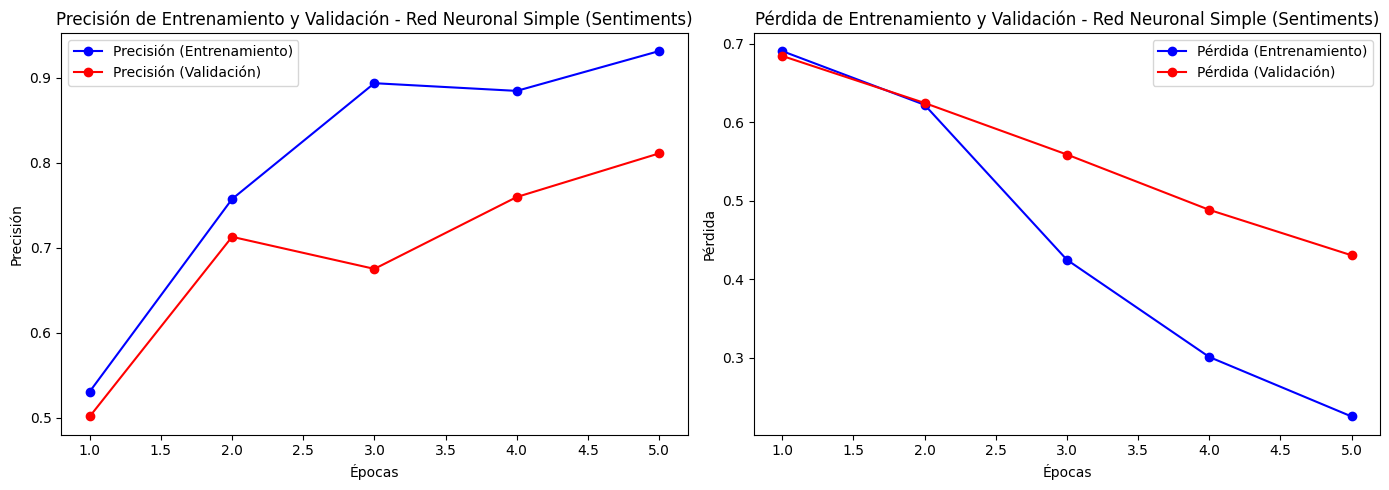

In [ ]:
graficos(history_simple_rnn_sentiments, "Red Neuronal Simple (Sentiments)")

Como se puede observar en la gráfica de la izquierda, la precisión sube de forma abrubpta tanto en entrenamiento como en validación. En la parte final se muestra que la precisión del entrenamiento es mejor que la de prueba.

Por otra parte, en la gráfica de la derecha la pérdida baja en ambos casos pero es más pronunciada en la de entrenamiento con respecto a la de validación, lo que puede indicar un sobreajuste nuevamente.

In [ ]:
resultados_simplernn_sentiments = model_simple_rnn_sentiments.evaluate(X_test_pad, y_test, verbose=2)
print(f"Pérdida: {resultados_simplernn_sentiments[0]:.4f}")
print(f"Precisión: {resultados_simplernn_sentiments[1]*100:.2f}%")

21/21 - 0s - 12ms/step - accuracy: 0.8112 - loss: 0.4304
Pérdida: 0.4304
Precisión: 81.12%


### 2.2. Entrenar un modelo con LSTM



In [ ]:
t_vocabulario = 10000
longitud_maxima = 200
embedding_dim = 32
rnn_units = 64

model_lstm_sentiments = LSTMModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    rnn_units=rnn_units
)

In [ ]:
model_lstm_sentiments.compile(loss='binary_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

model_lstm_sentiments.summary()

history_lstm_sentiments = model_lstm_sentiments.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Model: "lstm_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.5217 - loss: 0.6922 - val_accuracy: 0.7205 - val_loss: 0.6730
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.7531 - loss: 0.6272 - val_accuracy: 0.4955 - val_loss: 3.9338
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.5942 - loss: 2.0786 - val_accuracy: 0.7704 - val_loss: 0.5418
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.8758 - loss: 0.4348 - val_accuracy: 0.8082 - val_loss: 0.4632
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.9150 - loss: 0.3229 - val_accuracy: 0.8051 - val_loss: 0.4406


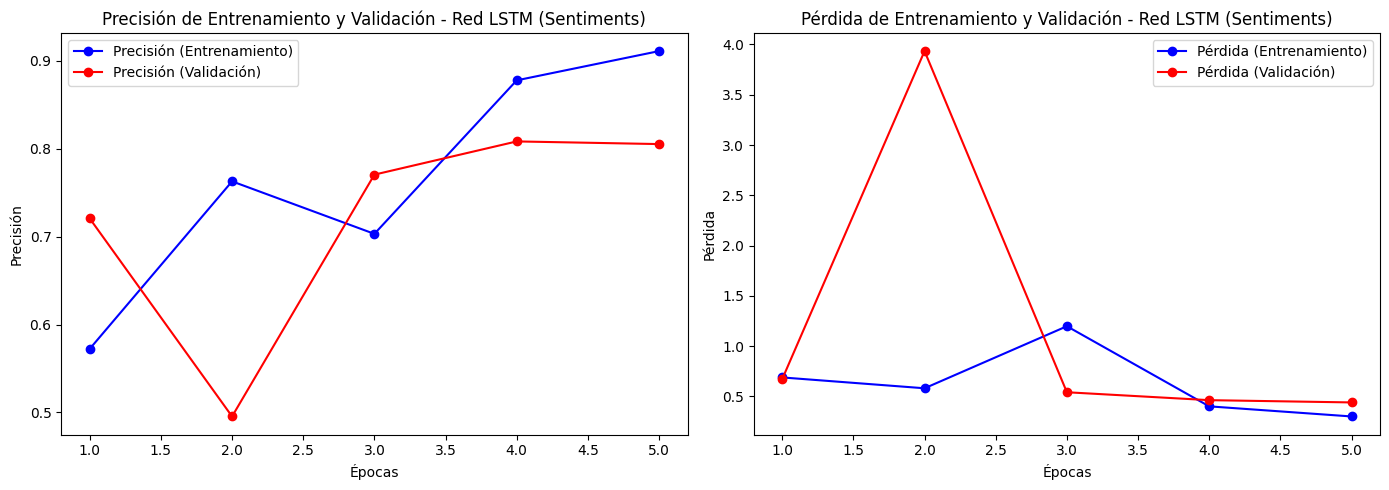

In [ ]:
graficos(history_lstm_sentiments, "Red LSTM (Sentiments)")

La LSTM para este conjunto de datos se comporta similar a la anterior pero con la diferencia que se realiza de una manera muy inestable. Los cambios abruptos que existen en las gráficas indican que puede que alguno de los hiperparámetros no estén funcionando correctamente, sin embargo la precisión alcanzada es parecida al anterior.

Con respecto a la pérdida ocurre lo mismo, esos cambios abruptos "no deberían" estar  ahí.

In [ ]:
resultados_lstm_sentiments = model_lstm_sentiments.evaluate(X_test_pad, y_test, verbose=2)
print(f"Pérdida: {resultados_lstm_sentiments[0]:.4f}")
print(f"Precisión: {resultados_lstm_sentiments[1]*100:.2f}%")

21/21 - 1s - 25ms/step - accuracy: 0.8051 - loss: 0.4406
Pérdida: 0.4406
Precisión: 80.51%


2.3 Entrenando el modelo Bidireccional apilado LSTM.

Finalmente para este modelo se usan los mismos parámetros que con los datos IMDB.

In [ ]:
t_vocabulario = 10000
longitud_maxima = 200
embedding_dim = 64
lstm_units = 128
dropout = 0.4

model_bi_lstm_sentiments = LSTMBIStackModel(
    vocab_size=t_vocabulario,
    embedding_dim=embedding_dim,
    max_length=longitud_maxima,
    lstm_units=lstm_units,
    dropout_rate=dropout
)

In [ ]:
model_bi_lstm_sentiments.compile(loss='binary_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])

model_bi_lstm_sentiments.summary()

history_bi_lstm_sentiments = model_bi_lstm_sentiments.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)

Model: "lstmbi_stack_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.4810 - loss: 0.6955 - val_accuracy: 0.4955 - val_loss: 0.6924
Epoch 2/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.5359 - loss: 0.6895 - val_accuracy: 0.7538 - val_loss: 0.5477
Epoch 3/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 119s 3s/step - accuracy: 0.7745 - loss: 0.4763 - val_accuracy: 0.8006 - val_loss: 0.4800
Epoch 4/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.9010 - loss: 0.2579 - val_accuracy: 0.7462 - val_loss: 0.5620
Epoch 5/5
42/42 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9110 - loss: 0.2309 - val_accuracy: 0.7900 - val_loss: 0.5642


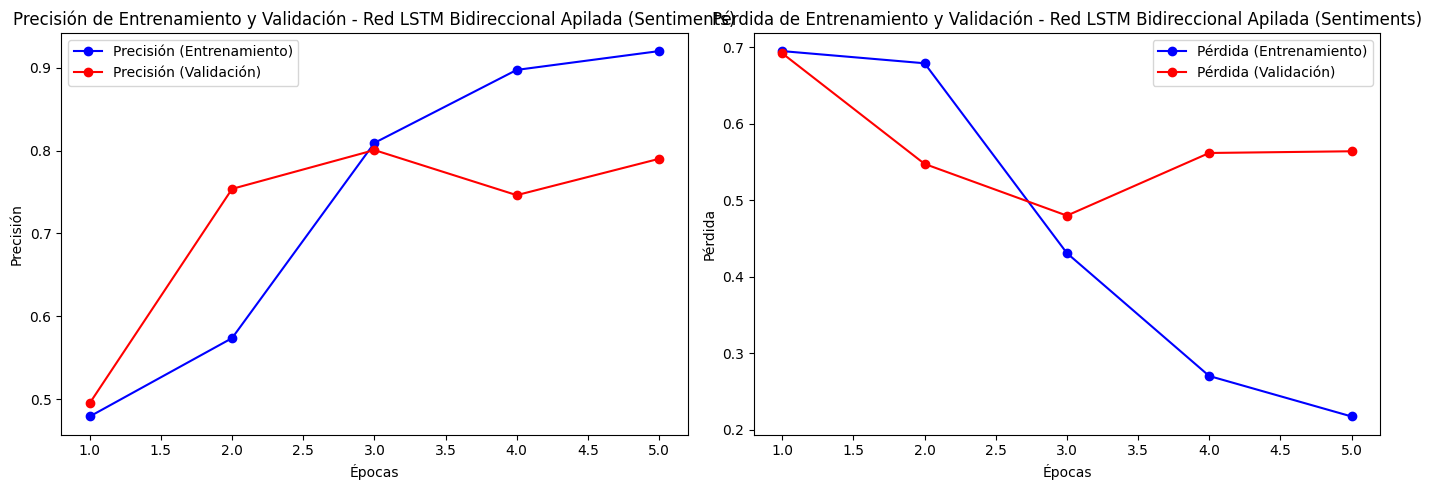

In [ ]:
graficos(history_bi_lstm_sentiments,"Red LSTM Bidireccional Apilada (Sentiments)")

De acuerdo a la gráfica de la izquierda, ambas precisiones mejoran pero con ligeros desbalances.

Con respecto a la de la derecha, después de la época 3, en la gráfica de validación se muestra que la pérdida vuelve a subir, mientras que la pérdida de entrenamiento baja de manera "normal". Esto quiere decir que durante las 3 primeras épocas generaliza bien pero después comienza un desbalance y posible sobreajuste en los datos. Se puede decir de alguna manera que este modelo es "potente" y por lo tanto no necesita tantas épocas para generalizar.

In [ ]:
resultados_bi_lstm_sentiments = model_bi_lstm_sentiments.evaluate(X_test_pad, y_test, verbose=2)
print(f"Pérdida: {resultados_bi_lstm_sentiments[0]:.4f}")
print(f"Precisión: {resultados_bi_lstm_sentiments[1]*100:.2f}%")

21/21 - 6s - 279ms/step - accuracy: 0.7900 - loss: 0.5642
Pérdida: 0.5642
Precisión: 79.00%


## Conclusión

Como se pudo observar, las redes en el conjunto de datos de IMBD fueron "malas" en comparación con el otro conjunto de datos. Esto puede deberse principalmente a que el conjunto IMDB es muy grande en comparación del conjunto de análisis de sentimientos y por ende necesita otras configuraciones y más épocas para poder tener un rendimiento mejor al que se generó. De igual forma, en ambos casos el sobreajuste se vio presente con las gráficas de pérdida y validación. En ambos casos, la red bidireccional LSTM apilada tuvo mejor rendimiento. Fue la única en resolver el problema con IMDB y la aprende más rápido con el conjunto de sentimientos, pero con la diferencia que se tiene que controlar debido a que no necesita tantas épocas ya que se sobreajusta muy rápido.